In [1]:
import black
import jupyter_black

jupyter_black.load(
    lab=False,
    line_length=79,
    target_version=black.TargetVersion.PY39,)

In [2]:
import numpy as np
from boolean_analysis import calculate_fourier_transform_matrix, parity_of_1s
import pandas as pd
from tqdm import tqdm
import pickle
from boolean_fourier_learner import BooleanFourierLearner
from pathlib import Path
import lzma
import parse
from spin_lattices import KagomeLattice
from misc_utils import make_unpacked_configurations
import matplotlib.pyplot as plt
from heisenberg_hamiltonians import batched_state_info_df, HeisenbergJ1J2
import lattice_symmetries as ls
import seaborn as sns

%matplotlib inline

In [3]:
experiment_dir = Path("kagome24-2022-12-22-1/")

In [4]:
learners = {}
for file in experiment_dir.glob("fourier-learner-*.pickle.lz"):
    J, i = parse.search("fourier-learner-{}-{:d}.pickle.lz", str(file)).fixed
    J = float(J)
    with lzma.open(file) as f:
        learners[J, i] = pickle.load(f)

learners_ser = (
    pd.DataFrame(dict(learner=learners))
    .reset_index()
    .rename(columns={"level_0": "J", "level_1": "iterations"})
).set_index(["J", "iterations"])["learner"]

for learner in learners.values():
    learner.coeffs_df_ = None

In [5]:
train_sets = {}
for file in experiment_dir.glob("train-*.feather"):
    (J,) = parse.search("train-{}.feather", str(file)).fixed
    J = float(J)
    train_sets[J] = pd.read_feather(file).set_index("index")

In [6]:
index = learners_ser[0.0, 400].get_coeffs_df().iloc[:20].index
for i in range(0, 500, 400):
    learners_ser[0.0, i].get_coeffs_df().loc[index].plot.bar()

KeyError: (0.0, 400)

In [9]:
lat = KagomeLattice(width=2, height=4)

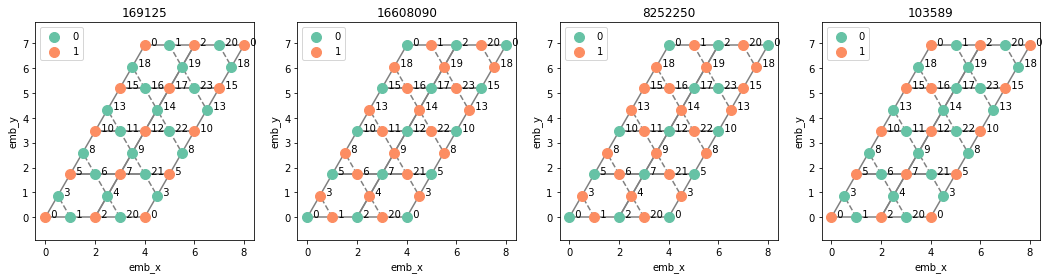

In [9]:
fig, axes = plt.subplots(ncols=4, figsize=(18, 4))
for i, ax in enumerate(axes):
    spins = int(learners_ser[0, 400].get_coeffs_df().index[i])
    lat.plot(spins=spins, ax=ax)
    ax.set_title(spins)

In [10]:
system = HeisenbergJ1J2(lat, J1=1, J2=0, use_symmetries=True)

fourier_basis = ls.SpinBasis(
    system.symmetry_group,
    number_spins=system.number_spins,
    hamming_weight=None,
    spin_inversion=None,
)
fourier_basis.build()

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662


In [11]:
state_info_df = batched_state_info_df(
    fourier_basis, np.arange(2**system.number_spins, dtype="uint64")
)

In [12]:
multiplicities = (
    state_info_df.reset_index()
    .rename(columns={"index": "subset"})
    .groupby("representative")
    .size()
)

In [13]:
learners_ser[1.2, 400].get_coeffs_df().assign(
    multiplicities=multiplicities
).iloc[:10]

,coeff,multiplicities
15833190,-0.14092,2
3382374,-0.13592,8
848700,-0.13572,2
848730,-0.13004,8
7572646,-0.12696,4
1993528,-0.12308,4
3762597,-0.12024,8
242487,-0.11556,8
1635149,0.11436,16
1665869,0.11340,8


In [14]:
multiplicities.value_counts()

16    1041432
8       14022
4         506
2          48
1           8
dtype: int64

In [12]:
from boolean_analysis import calculate_fourier_transform_matrix

In [13]:
def expand_fourier_coeffs(coeffs, fourier_basis, number_spins):
    state_info_df = batched_state_info_df(
        fourier_basis, np.arange(2**number_spins, dtype="uint64")
    )
    return state_info_df.join(coeffs, on="representative")["coeff"].dropna()

In [14]:
def predict(coeffs, x, number_spins):
    transform_matrix = calculate_fourier_transform_matrix(
        states=x,
        subsets=np.array(coeffs.index, dtype="uint64"),
        number_spins=number_spins,
        show_progress=True,
    )
    return transform_matrix @ coeffs

In [15]:
state_info_df_system = (
    batched_state_info_df(system.basis, system.canonical_basis.states)
    .reset_index()
    .rename(columns={"index": "state"})
)
state_info_df_system

,state,representative,character,norm
0,4095,4095,1.0+0.0j,0.176777
1,6143,6143,1.0+0.0j,0.176777
2,7167,7167,1.0+0.0j,0.176777
3,7679,7679,1.0+0.0j,0.176777
4,7935,7935,1.0+0.0j,0.176777
...,...,...,...,...
2704151,16769280,7935,1.0+0.0j,0.176777
2704152,16769536,7679,1.0+0.0j,0.176777
2704153,16770048,7167,1.0+0.0j,0.176777
2704154,16771072,6143,1.0+0.0j,0.176777


In [16]:
def mk_test_set(system, train, size=10000):
    state_info_df_system = (
        batched_state_info_df(system.basis, system.canonical_basis.states)
        .reset_index()
        .rename(columns={"index": "state"})
    )
    return np.random.choice(
        state_info_df_system.merge(
            batched_state_info_df(system.basis, np.array(train))
            .reset_index()
            .rename(columns={"index": "train_state"}),
            on="representative",
            how="outer",
        )[lambda x: x["train_state"].isnull()]["state"],
        size=size,
        replace=False,
    )

In [17]:
mk_test_set(system, train_sets[0.51].index).shape

KeyError: 0.51

In [18]:
def sign_overlap(sign_pred, eigenstate):
    amplitudes = np.abs(eigenstate)
    return (np.sign(sign_pred) * amplitudes * eigenstate).sum() / (
        amplitudes**2
    ).sum()

In [19]:
learners_ser

J      iterations
0.502  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourierLearner...
       150           <boolean_fourier_learner.BooleanFourierLearner...
       200           <boolean_fourier_learner.BooleanFourierLearner...
0.540  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourierLearner...
       150           <boolean_fourier_learner.BooleanFourierLearner...
       200           <boolean_fourier_learner.BooleanFourierLearner...
Name: learner, dtype: object

In [20]:
batch_size = 100


def calculate_overlap(keep_coeffs=100, test_set_size=1000):
    datapoints = []

    if isinstance(keep_coeffs, int):
        keep_coeffs = [keep_coeffs]

    for keep_coeff in tqdm(keep_coeffs):
        for (J2, iterations), learner in tqdm(learners_ser.items()):
            if iterations == 0:
                continue
            system = HeisenbergJ1J2(lat, J1=1, J2=J2, use_symmetries=True)
            system.get_eigenstates()

            train = train_sets[J2]

            train_set_size = batch_size * iterations
            train_eps = train_set_size / len(system.canonical_basis.states)

            test_states = mk_test_set(system, train.index, size=test_set_size)
            coeffs_expanded = expand_fourier_coeffs(
                learner.get_coeffs_df().iloc[:keep_coeff],
                fourier_basis,
                system.number_spins,
            )

            coeffs_kept_full = len(coeffs_expanded)

            coeffs_eps = coeffs_kept_full / 2**system.number_spins

            prediction = predict(
                coeffs_expanded,
                test_states,
                system.number_spins,
            )

            test_eigenstate = system.get_df_eigenstate(
                k=0, canonical_basis=True
            ).loc[test_states, "eigenstate_coeff"]

            overlap = sign_overlap(prediction, test_eigenstate)
            datapoints.append(
                [
                    J2,
                    iterations,
                    train_set_size,
                    train_eps,
                    test_set_size,
                    keep_coeff,
                    coeffs_kept_full,
                    coeffs_eps,
                    overlap,
                ]
            )
    df = pd.DataFrame(
        datapoints,
        columns=[
            "J2",
            "iterations",
            "train_set_size",
            "train_eps",
            "test_set_size",
            "keep_coeff",
            "coeffs_kept_fill",
            "coeffs_eps",
            "overlap",
        ],
    )
    return df

In [21]:
overlap_df_full = calculate_overlap(
    keep_coeffs=[2, 10, 50, 100, 500, 2000, 10000]
)

  0%|          | 0/7 [00:00<?, ?it/s]
0it [00:00, ?it/s]

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.502-True-1-1.pickle
Ground state energy is -39.4488520059




100%|██████████| 24/24 [00:00<00:00, 25977.62it/s]

1it [00:18, 18.04s/it]

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.502-True-1-1.pickle
Ground state energy is -39.4488520059




100%|██████████| 24/24 [00:00<00:00, 26441.63it/s]

2it [00:35, 17.89s/it]

...



  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:15<05:51, 15.28s/it]

  8%|▊         | 2/24 [00:20<03:27,  9.43s/it]

 12%|█▎        | 3/24 [00:24<02:28,  7.07s/it]

 17%|█▋        | 4/24 [00:29<02:00,  6.05s/it]

 21%|██        | 5/24 [00:33<01:44,  5.48s/it]

 25%|██▌       | 6/24 [00:39<01:37,  5.41s/it]

 29%|██▉       | 7/24 [00:42<01:22,  4.88s/it]

 33%|███▎      | 8/24 [00:46<01:12,  4.51s/it]

 38%|███▊      | 9/24 [00:50<01:06,  4.41s/it]

 42%|████▏     | 10/24 [00:55<01:02,  4.43s/it]

 46%|████▌     | 11/24 [01:00<01:00,  4.67s/it]

 50%|█████     | 12/24 [01:12<01:23,  6.98s/it]

 54%|█████▍    | 13/24 [01:22<01:26,  7.88s/it]

 58%|█████▊    | 14/24 [01:33<01:26,  8.68s/it]

 62%|██████▎   | 15/24 [01:38<01:09,  7.75s/it]

 67%|██████▋   | 16/24 [01:41<00:50,  6.31s/it]

 71%|███████   | 17/24 [01:45<00:38,  5.45s/it]

 75%|███████▌  | 18/24 [01:52<00:35,  5.96s/it]

 79%|███████▉  | 19/24 [01:56<00:26,  5.32s/it]

 83%|████████▎ | 20/24 [02:25<00:50,

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.54-True-1-1.pickle
Ground state energy is -39.2319828007




  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:03<01:08,  3.00s/it]

  8%|▊         | 2/24 [00:06<01:06,  3.03s/it]

 12%|█▎        | 3/24 [00:08<01:02,  2.98s/it]

 17%|█▋        | 4/24 [00:11<00:59,  2.96s/it]

 21%|██        | 5/24 [00:13<00:45,  2.41s/it]

 25%|██▌       | 6/24 [00:14<00:36,  2.00s/it]

 29%|██▉       | 7/24 [00:15<00:29,  1.75s/it]

 33%|███▎      | 8/24 [00:16<00:25,  1.57s/it]

 38%|███▊      | 9/24 [00:18<00:21,  1.46s/it]

 42%|████▏     | 10/24 [00:19<00:19,  1.38s/it]

 46%|████▌     | 11/24 [00:20<00:17,  1.32s/it]

 50%|█████     | 12/24 [00:21<00:15,  1.29s/it]

 54%|█████▍    | 13/24 [00:22<00:13,  1.26s/it]

 58%|█████▊    | 14/24 [00:24<00:12,  1.25s/it]

 62%|██████▎   | 15/24 [00:25<00:11,  1.24s/it]

 67%|██████▋   | 16/24 [00:26<00:09,  1.23s/it]

 71%|███████   | 17/24 [00:27<00:08,  1.22s/it]

 75%|███████▌  | 18/24 [00:29<00:07,  1.22s/it]

 79%|███████▉  | 19/24 [00:30<00:06,  1.21s/it]

 83%|████████▎ | 20/24 [00:31<00:04,

self.number_spins=24
Symmetry group contains 16 elements
Hilbert space dimension is 85662
Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.54-True-1-1.pickle
Ground state energy is -39.2319828007




  0%|          | 0/24 [00:00<?, ?it/s]

  4%|▍         | 1/24 [00:01<00:33,  1.46s/it]

  8%|▊         | 2/24 [00:02<00:31,  1.44s/it]

 12%|█▎        | 3/24 [00:04<00:30,  1.44s/it]

 17%|█▋        | 4/24 [00:05<00:28,  1.43s/it]

 21%|██        | 5/24 [00:07<00:27,  1.43s/it]

 25%|██▌       | 6/24 [00:08<00:25,  1.43s/it]

 29%|██▉       | 7/24 [00:10<00:24,  1.43s/it]

 33%|███▎      | 8/24 [00:11<00:22,  1.44s/it]

 38%|███▊      | 9/24 [00:12<00:21,  1.44s/it]

 42%|████▏     | 10/24 [00:14<00:20,  1.44s/it]

 46%|████▌     | 11/24 [00:15<00:18,  1.43s/it]

 50%|█████     | 12/24 [00:17<00:17,  1.43s/it]

 54%|█████▍    | 13/24 [00:18<00:15,  1.43s/it]

 58%|█████▊    | 14/24 [00:20<00:14,  1.43s/it]

 62%|██████▎   | 15/24 [00:21<00:12,  1.43s/it]

 67%|██████▋   | 16/24 [00:22<00:11,  1.43s/it]

 71%|███████   | 17/24 [00:24<00:09,  1.43s/it]

 75%|███████▌  | 18/24 [00:25<00:08,  1.43s/it]

 79%|███████▉  | 19/24 [00:27<00:07,  1.43s/it]

 83%|████████▎ | 20/24 [00:28<00:05,

In [30]:
len(fourier_basis.states)

1056016

In [79]:
overlap_df_full.to_feather(experiment_dir / "overlap-uniform.feather")

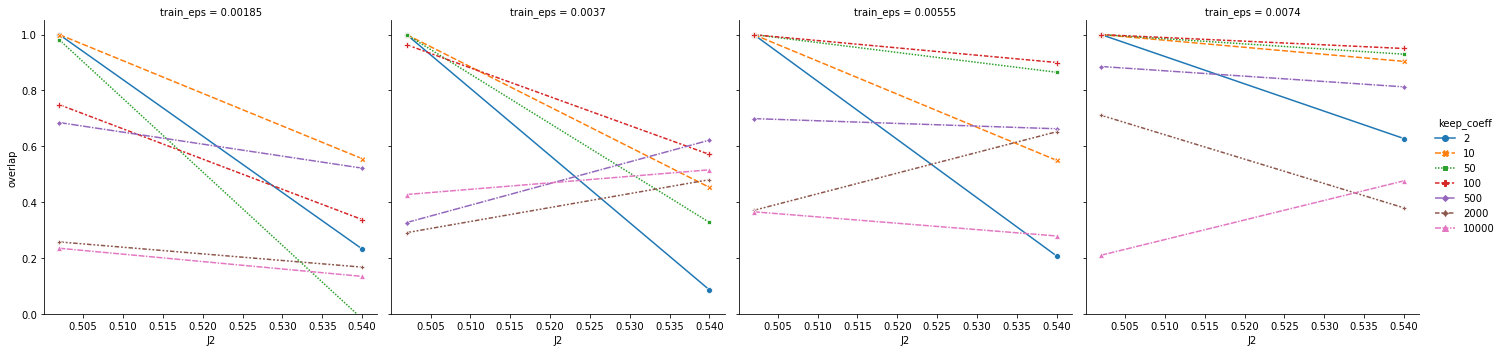

In [23]:
sns.relplot(
    overlap_df_full.assign(
        keep_eps=lambda x: np.round(
            (x["keep_coeff"] / len(fourier_basis.states)), 5
        ).astype(str),
        keep_coeff=lambda x: x["keep_coeff"].astype("str"),
        train_eps=lambda x: np.round(x["train_eps"], 5),
    )
    # .assign(iterations=lambda x: x["iterations"].astype(str))
    ,
    x="J2",
    y="overlap",
    hue="keep_coeff",
    style="keep_coeff",
    markers=True,
    col="train_eps",
    kind="line",
).set(ylim=(0, None))
plt.savefig("kagome24-predict.pdf")

In [36]:
learner_multipliticities = []
for keep_first in [5, 10, 20, 100]:
    for J2, learner in learners_ser.swaplevel()[400].items():
        mean_multiplicity = (
            learner.get_coeffs_df()
            .assign(multiplicities=multiplicities)
            .iloc[:keep_first]["multiplicities"]
            .mean()
        )
        learner_multipliticities.append([J2, keep_first, mean_multiplicity])

learner_multipliticities = pd.DataFrame(
    learner_multipliticities,
    columns=["J2", "keep_first", "mean_multiplicity"],
)

In [50]:
(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
)

,index,coeff,abs_coeff
0,15833190,-0.14092,0.14092
1,3382374,-0.13592,0.13592
2,848700,-0.13572,0.13572
3,848730,-0.13004,0.13004
4,7572646,-0.12696,0.12696
...,...,...,...
95,5475214,0.08548,0.08548
96,3765061,0.08532,0.08532
97,3335782,0.08504,0.08504
98,15820902,-0.08488,0.08488


In [53]:
(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index(drop=True)
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"]))
)

,index,coeff,abs_coeff
0,0,-0.14092,0.14092
1,1,-0.13592,0.13592
2,2,-0.13572,0.13572
3,3,-0.13004,0.13004
4,4,-0.12696,0.12696
...,...,...,...
95,95,0.08548,0.08548
96,96,0.08532,0.08532
97,97,0.08504,0.08504
98,98,-0.08488,0.08488


<AxesSubplot: xlabel='index', ylabel='abs_coeff'>

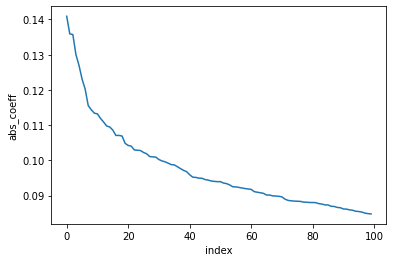

In [51]:
sns.lineplot(
    learner.get_coeffs_df()
    .iloc[:100]
    .reset_index(drop=True)
    .reset_index()
    .assign(abs_coeff=lambda x: np.abs(x["coeff"])),
    x="index",
    y="abs_coeff",
)

In [27]:
learners_ser

J      iterations
0.502  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourierLearner...
       150           <boolean_fourier_learner.BooleanFourierLearner...
       200           <boolean_fourier_learner.BooleanFourierLearner...
0.504  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourierLearner...
       150           <boolean_fourier_learner.BooleanFourierLearner...
       200           <boolean_fourier_learner.BooleanFourierLearner...
0.506  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourierLearner...
       150           <boolean_fourier_learner.BooleanFourierLearner...
       200           <boolean_fourier_learner.BooleanFourierLearner...
0.508  50            <boolean_fourier_learner.BooleanFourierLearner...
       100           <boolean_fourier_learner.BooleanFourie

In [74]:
first_100_coeffs = pd.concat(
    [
        (
            learner.get_coeffs_df()
            .reset_index(drop=True)
            .iloc[::1000]
            .reset_index()
            .assign(abs_coeff=lambda x: np.abs(x["coeff"]), J2=J2)
        )
        for J2, learner in learners_ser.swaplevel()[200][[0.52, 0.53]].items()
    ]
)

In [75]:
first_100_coeffs

,index,coeff,abs_coeff,J2
0,0,-1.000000e+00,1.000000e+00,0.52
1,1000,3.210000e-02,3.210000e-02,0.52
2,2000,2.510000e-02,2.510000e-02,0.52
3,3000,2.280000e-02,2.280000e-02,0.52
4,4000,-2.160000e-02,2.160000e-02,0.52
...,...,...,...,...
1052,1052000,1.409463e-18,1.409463e-18,0.53
1053,1053000,9.757820e-19,9.757820e-19,0.53
1054,1054000,-6.369688e-19,6.369688e-19,0.53
1055,1055000,3.252607e-19,3.252607e-19,0.53


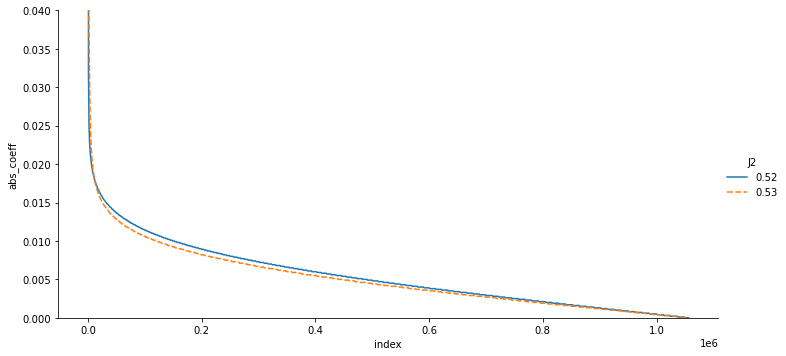

In [76]:
sns.relplot(
    first_100_coeffs.assign(J2=lambda x: x["J2"].astype(str)),
    x="index",
    y="abs_coeff",
    hue="J2",
    kind="line",
    style="J2",
    aspect=2,
).set(ylim=(0, 0.04))

<AxesSubplot: xlabel='J2', ylabel='mean_multiplicity'>

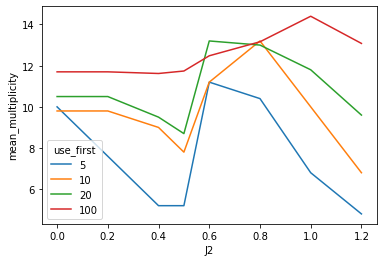

In [39]:
sns.lineplot(
    learner_multipliticities.assign(
        use_first=lambda x: x["keep_first"].astype(str)
    ),
    x="J2",
    y="mean_multiplicity",
    hue="use_first",
)

In [197]:
(learner.get_coeffs_df().assign(multiplicities=multiplicities).iloc[:10])

,coeff,multiplicities
15833190,-0.14092,2
3382374,-0.13592,8
848700,-0.13572,2
848730,-0.13004,8
7572646,-0.12696,4
1993528,-0.12308,4
3762597,-0.12024,8
242487,-0.11556,8
1635149,0.11436,16
1665869,0.11340,8
